# [IAPR][iapr]: Lab 2 ‒  Object description

**Group ID:** XXXX

**Author 1 (sciper):** Juliette Parchet (295888)
**Author 2 (sciper):** Thomas Berkane (297780)
**Author 3 (sciper):** Merhad Sahebi (354506)

**Release date:** 24.03.2023  
**Due date:** 07.04.2023 (11:59 pm)


## Important notes

The lab assignments are designed to teach practical implementation of the topics presented during class well as
preparation for the final project, which is a practical project which ties together the topics of the course.

As such, in the lab assignments/final project, unless otherwise specified, you may, if you choose, use external
functions from image processing/ML libraries like opencv and sklearn as long as there is sufficient explanation
in the lab report. For example, you do not need to implement your own edge detector, etc.

**! Before handling back the notebook <font color='red'> rerun </font>the notebook from scratch !**
`Kernel` > `Restart & Run All`

We will not rerun the notebook for you.


[iapr]: https://github.com/LTS5/iapr

In [2]:
import os
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import skimage.io
from scipy import ndimage
from scipy.interpolate import splprep, splev
from skimage import measure, filters
% matplotlib inline

UsageError: Line magic function `%` not found.


---
## 0. Extract relevant data
We first need to extract the `lab-02-data.tar.gz` archive.
To this end, we use the [tarfile] module from the Python standard library. In the `lab-02-data` folder, you will find 28x28 grey-scale pictures of handwritten "0", "1", "2" and "3".
These digits have been extracted from MNIST dataset (http://yann.lecun.com/exdb/mnist/).

[tarfile]: https://docs.python.org/3.6/library/tarfile.html

In [3]:
data_base_path = os.path.join(os.pardir, 'data')
data_folder = 'lab-02-data'
data_part1 = os.path.join(data_base_path, data_folder, 'part1')
data_part2 = os.path.join(data_base_path, data_folder, 'part2')

tar_path = os.path.join(data_base_path, data_folder + '.tar.gz')
with tarfile.open(tar_path, mode='r:gz') as tar:
    tar.extractall(path=data_base_path)

### 0.1.Data visualization

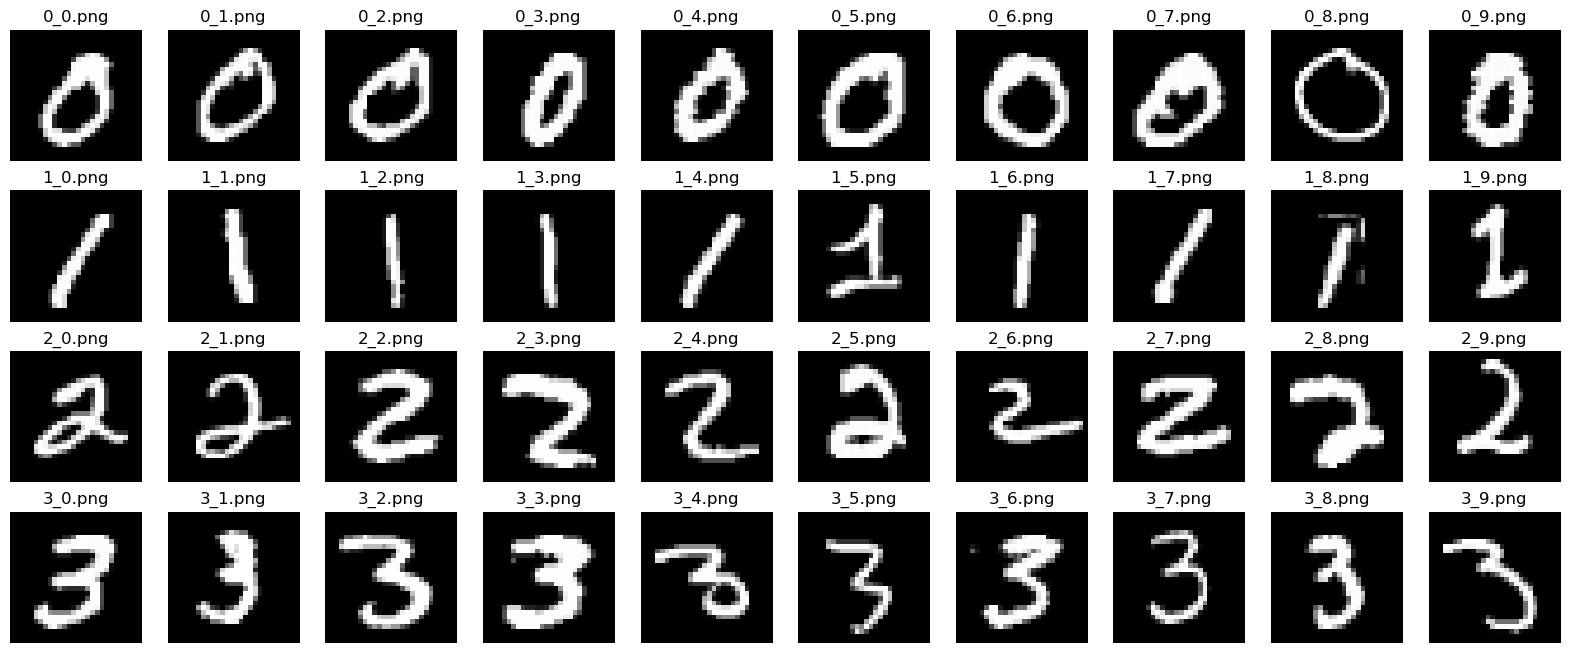

In [4]:
def load(path, digit='0'):
    digit_path = os.path.join(path, digit)
    digit_names = [nm for nm in os.listdir(digit_path) if '.png' in nm]  # make sure to only load .png
    digit_names.sort()  # sort file names
    ic = skimage.io.imread_collection([os.path.join(digit_path, nm) for nm in digit_names])
    digit_im = skimage.io.concatenate_images(ic)
    return digit_im, digit_names


# Load digits data

# Zero images arrays
zeros_im, zeros_names = load(data_part1, digit='0')
# Ones images arrays
ones_im, ones_names = load(data_part1, digit='1')
# Twos images arrays
twos_im, twos_names = load(data_part2, digit='2')
# Threes images arrays
threes_im, threes_names = load(data_part2, digit='3')

# Plot images
fig, axes = plt.subplots(4, len(zeros_im), figsize=(20, 8))
for ax, im, nm in zip(axes[0], zeros_im, zeros_names):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(nm)
for ax, im, nm in zip(axes[1], ones_im, ones_names):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(nm)
for ax, im, nm in zip(axes[2], twos_im, twos_names):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(nm)
for ax, im, nm in zip(axes[3], threes_im, threes_names):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(nm)

---
## Part 1 - contour based descriptors (18 pts)

In this part you will use images of "0"s and "1"s.

**Objectives overview**: Fourier Descriptors


**1)** *Preprocess*: Select ONLY "0" and "1" images and apply suitable preprocessing. Show a plot with the preprocessed data and give arguments on the chosen techniques. (**2 pts**)


**2)** *Get descriptors*: Find the contours and get the Fourier descriptors in complex definition. *Note*: The contours arrays should contain a finite number (N-> self-chosen) of equi-distant points for each image (hint: interpolation). In the case of the "0" contours, just keep the outermost contour. Discuss the necessity of this format. (**4 pts**)
    
    
**3)** *Study effect of descriptors* : Show the contour-reconstruction of the digits using different amount of descriptors (both for ONE "0" image and ONE "1" image)
- Make 5 plots, reconstructing the digits' countours using different amounts of descriptors. (e.g. reconstruct the contour using the only the 1st fourier descriptor, reconstruct using the first two fourier descriptors,  using the first three ...)  
- **Hint**: check scipy fft, ifft, and fftfreq functions (see [link](https://docs.scipy.org/doc/scipy/tutorial/fft.html)) and pay attention on the ordering, observing which coefficients correspond to positive/negative frequencies of components and how you choose your low frequency subsets . 
- **Extra hint** To reconstruct the contour, copy the original vector of the fourier descriptors, keep the positive an negative frequencies you will use, and set to 0 the rest. (e.g. If you want to reconstruc the image with the first _three fourier descriptors_, keep the first _three positive frecuencies_ and their respective _three negative frequencies_ (see positive and negative bin freque
    frequencies [link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fftfreq.html#scipy.fft.fftfreq) ). 
- Discuss about your findings. (**4 pts**)
    
        
**4)** *Clustering*: For each image containing a "0" or a "1", using the fourier descriptors, extract a 2-dimensional feature vector (using the THE POSITIVE bin frequencies from fftfreq, see [link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fftfreq.html#scipy.fft.fftfreq) ) and plot all of them on a 2D graph. Did you obtain a plot where the vectors of the "0"'s nicely cluster in one part of the plane and those of the "1"'s in the other? If yes, explain why. (**2 pts**)
    
    
**5)** *Show translation, rotation and scale invariance*
- Firstly, discuss which descriptors, or which part of the descriptors are affected by each transformation. For each transformation define (write in words) an operation which will be applied to the descriptor arrays, such that they will be invariant to (not affected by) the specific transformation anymore. After finding the necessary operations, define a function that will make the Fourier descriptors invariant to all the transformations, altogether.(**3 pts**) 
- Secondly, show that if you are using descriptors invariant to transformations, you still obtain 2 nicely defined clusters for the 2 categories of numbers, under transformations applied. (You need to define custom functions for each transformation, apply them on images, and compare the obtained invariant descriptors). Discuss your findings. (**3 pts**)

### 1. Fourier Descriptors

### 1.1. Preprocess and visualization (2 pts)

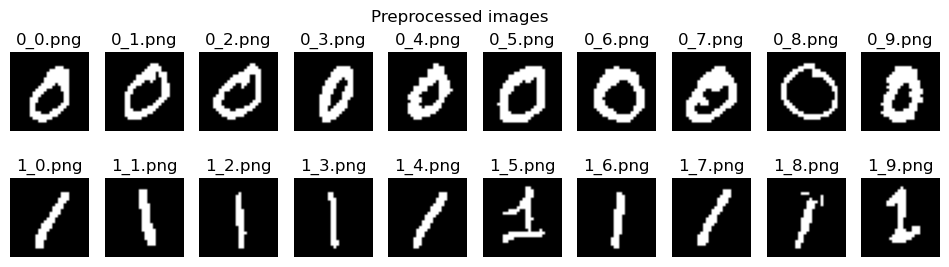

In [5]:
zeros = [im > filters.threshold_otsu(im) for im in zeros_im]
ones = [im > filters.threshold_otsu(im) for im in ones_im]

# Plot images
fig, axes = plt.subplots(2, len(zeros), figsize=(12, 3))
for ax, im, nm in zip(axes[0], zeros, zeros_names):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(nm)
for ax, im, nm in zip(axes[1], ones, ones_names):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(nm)
fig.suptitle("Preprocessed images")
plt.show()

#### Discussion

The images are already quite clean (digits centered, no bluriness, etc.) so the only preprocessing which we apply is to threshold the images to convert them to binary images to get cleaner contours.

### 1.2. Get descriptors (4 pts)

In [6]:
def find_equidistant_points(contour, N):
    """
    :param contour: list of 2D points representing the contour
    :param N: number of equi-distant points to find
    :return: list of N equidistant 2D points on the contour
    """
    # Create a spline representation of the contour
    tck, u = splprep(np.array(contour).T, s=0, per=True)

    # Generate N equi-distant parameter values for the spline
    parameter_values = np.linspace(0, 1, N + 1)[:-1]

    # Evaluate the spline at the equi-distant parameter values to get N equi-distant points
    equidistant_points = splev(parameter_values, tck)
    equidistant_points = np.array(equidistant_points).T

    return equidistant_points


def get_descriptors(img):
    """
    :param img: image for which to compute the descriptors
    :return: set of descriptors
    """
    # Find the contours of the binary image
    contours = measure.find_contours(img, 0.5)

    # Select the largest contour
    largest_contour = max(contours, key=len)
    # plt.plot(largest_contour[:,0], largest_contour[:,1])
    # plt.show()
    equidist_contour = find_equidistant_points(largest_contour, 68)

    # Reshape the contour to a single row of complex numbers
    contour_complex = equidist_contour[:, 0] + 1j * equidist_contour[:, 1]
    descriptors = np.fft.fft(contour_complex)

    return descriptors


# Check first 10 descriptors of a test image (just to check that your pipeline works well)
print(get_descriptors(zeros_im[0])[:10])

[ 1.00299752e+03+954.47031826j  8.46519737e+01 -90.10640655j
 -2.40347903e+01  +7.05350113j  2.57681277e+00 -10.05671285j
  7.01747305e+00  -5.98352836j -4.11915818e+00  +6.29604089j
  1.78234620e+00  +1.43238752j  1.62684574e+00  -1.42092979j
  8.34156355e-01  -2.05710182j  4.45893442e+00  -3.048752j  ]


#### Discussion

The contours must contain a constant number of equidistant points so that we calculate the same numbers of descriptors for each image. This way, descriptors for different images are comparable, which is useful in part 1.4 for instance. If we did not have the same number of descriptors between images then for some images we might have a more detailed representation in the Fourier domain while for others it would be less detailed.

### 1.3. Study effect of descriptors (6 pts)

In [7]:
# Define increasing set sizes of the descriptors. You can also change these numbers.
descr_set_sizes = [1, 2, 5, 10, 20]

# Define images for which you will show the recovery. You can also change the indexes.
zero = zeros_im[0]
one = ones_im[0]

In [8]:
def reconstruct_contour(descriptors, num_descriptors):
    """
    :param descriptors: set of descriptors used to reconstruct the contour
    :param num_descriptors: number of these descriptors to use
    :return: array of 2d coordinates representing the reconstructed contour
    """
    descriptors_copy = descriptors.copy()
    # set usused descriptors to 0
    descriptors_copy[num_descriptors + 1:len(descriptors_copy) - num_descriptors] = 0.
    ifft_descriptors = np.fft.ifft(descriptors_copy)
    contour = np.array([[z.real, z.imag] for z in ifft_descriptors])
    return contour

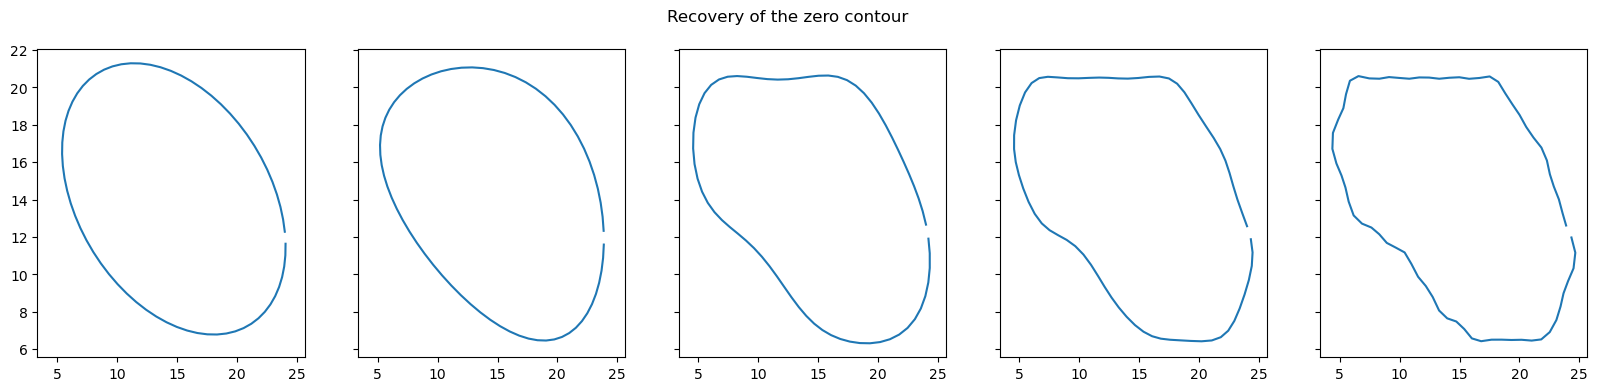

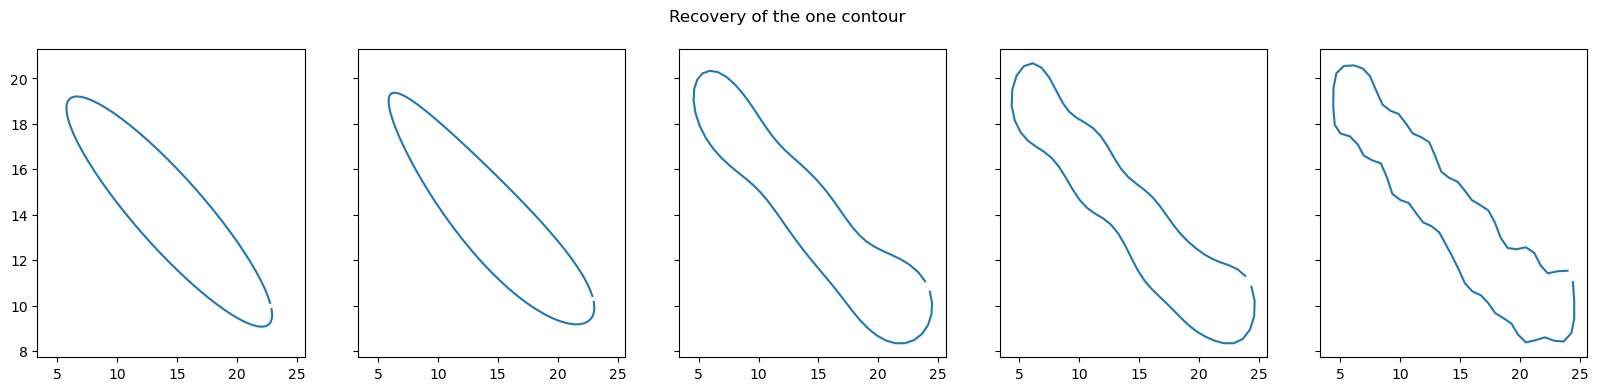

In [9]:
# On each of the 5 plots you will show the recovery for a "0" and a "1" (used the same axis for both a "0" and a "1").
zero_descriptors = get_descriptors(zero)
one_descriptors = get_descriptors(one)

# Plot recovery for a zero image
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for i in range(0, 5):
    reconstructed_contour = reconstruct_contour(zero_descriptors, descr_set_sizes[i])
    axes[i].plot(reconstructed_contour[:, 0], reconstructed_contour[:, 1])
fig.suptitle("Recovery of the zero contour")
plt.show()

# Plot recovery for a one image
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)
for i in range(0, 5):
    reconstructed_contour = reconstruct_contour(one_descriptors, descr_set_sizes[i])
    axes[i].plot(reconstructed_contour[:, 0], reconstructed_contour[:, 1])
fig.suptitle("Recovery of the one contour")
plt.show()

#### Discussion

As expected, when using more and more descriptors, the reconstructed contour becomes more detailed and noisy. For simple shapes such as 0 and 1, just using one or two descriptors seems to be enough to capture the shape of the digit.

### 1.4 Clustering (2 pts)

<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
/home/thomas/miniconda3/envs/iapr/lib/python3.9/site-packages/matplotlib/collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


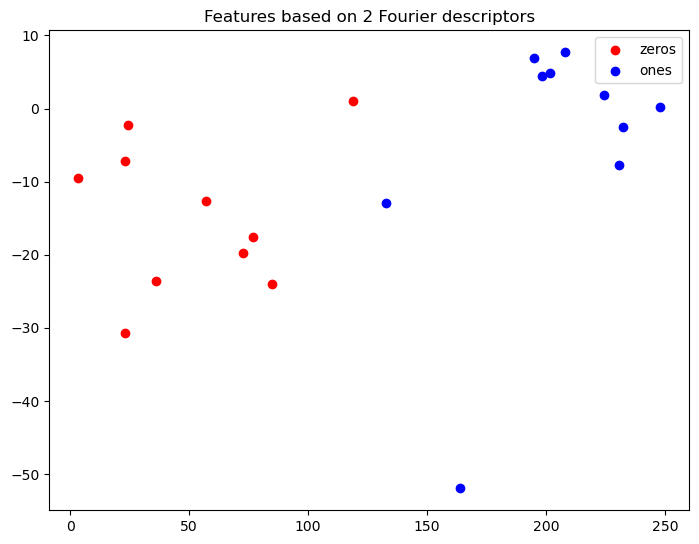

In [10]:

# First feature for all "0"s
zeros_f1 = [get_descriptors(img)[1] for img in zeros]
# Second feature for all "0"s
zeros_f2 = [get_descriptors(img)[2] for img in zeros]
# Fist feature for all "1"s
ones_f1 = [get_descriptors(img)[1] for img in ones]
# Second feature for all "1"s
ones_f2 = [get_descriptors(img)[2] for img in ones]

# Plot features for all images
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.scatter(zeros_f1, zeros_f2, color='r', label='zeros')
ax.scatter(ones_f1, ones_f2, color='b', label='ones')
ax.legend(loc='best')
plt.title("Features based on 2 Fourier descriptors")
plt.show()

#### Discussion


The points corresponding to 0 and 1 are quite well clustered together. In the 1s we have two outliers which correspond to the 1 digits which were written not just as a straight line.

### 1.5 Transformation invariance (6 pts)

#### Preliminary discussion

- Translation only affects the first Fourier descriptor, so we can set it to 0 to make the descriptors invariant to translation.
- Rotation affects the phase of all descriptors but not the amplitude, so we can take the modulus of each descriptor to make them invariant.
- Scaling does not change the ratio between pairs of descriptors, so we can choose one of the descriptors (the second one) and divide all descriptors by it to make them invariant to scaling.

#### Implementation

In [11]:
# a set of features invariant to scale, rotation and translation, according to function boolean parameters.
# You may use your functions defined in section 1.B.

def get_invariant_features(img, inv_to_rotation=False, inv_to_translation=False, inv_to_scale=False):
    """
    :param img: input image
    :param inv_to_rotation: whether to make image's features invariant to rotation
    :param inv_to_translation: whether to make image's features invariant to translation
    :param inv_to_scale: whether to make image's features invariant to scale
    :return: set of invariant features
    """
    descriptors = get_descriptors(img)
    if inv_to_translation:
        descriptors[0] = 0.
    if inv_to_rotation:
        descriptors = [abs(z) for z in descriptors]
    if inv_to_scale:
        div_by = descriptors[1]
        descriptors = [z / div_by for z in descriptors]
    return descriptors

In [12]:
# https://stackoverflow.com/questions/59241216/padding-numpy-arrays-to-a-specific-size
def padding(array, xx, yy):
    """
    Pads array to the desired dimensions
    :param array: numpy array
    :param xx: desired height
    :param yy: desirex width
    :return: padded array
    """

    h = array.shape[0]
    w = array.shape[1]

    a = (xx - h) // 2
    aa = xx - a - h

    b = (yy - w) // 2
    bb = yy - b - w

    return np.pad(array, pad_width=((a, aa), (b, bb)), mode='constant')

In [13]:
# Define custom rotation function. You may add other parameters to the function.
def random_rotate(img):
    """
    Applies a random rotation to image
    """
    angle = np.random.randint(-180, 180)
    new_img = ndimage.rotate(img, angle, reshape=False, cval=-0.5)
    return new_img


# Define custom rotation function. You may add other parameters to the function.
def random_translate(img):
    """
    Applies a random translation to image
    """
    shift = np.random.randint(-2, 2, 2)
    new_img = ndimage.shift(img, shift, cval=-0.5)
    return new_img


# Define custom rotation function. You may add other parameters to the function.
def random_scale(img):
    """
    Applies a random scaling to image
    """
    scale = np.random.randint(1, 5)
    new_img = ndimage.zoom(img, scale, cval=-0.5)
    new_img = padding(new_img, 112, 112) # make sure all output images have same size
    return new_img

In [14]:
# We will define 4 sets of new images below

rotated_images_zeros = [random_rotate(z) for z in zeros]
rotated_images_ones = [random_rotate(z) for z in ones]

translated_images_zeros = [random_translate(z) for z in zeros]
translated_images_ones = [random_translate(z) for z in ones]

scaled_images_zeros = [random_scale(z) for z in zeros]
scaled_images_ones = [random_scale(z) for z in ones]

transformed_images_zeros = [random_rotate(random_translate(random_scale(z))) for z in zeros]
transformed_images_ones = [random_rotate(random_translate(random_scale(z))) for z in ones]

In [15]:
def plot_descriptors(images_zeros, images_ones, i, j, title):
    zeros_f1 = [get_invariant_features(img, inv_to_rotation=True, inv_to_translation=True, inv_to_scale=True)[2] for img
                in images_zeros]
    zeros_f2 = [get_invariant_features(img, inv_to_rotation=True, inv_to_translation=True, inv_to_scale=True)[3] for img
                in images_zeros]
    ones_f1 = [get_invariant_features(img, inv_to_rotation=True, inv_to_translation=True, inv_to_scale=True)[2] for img
               in images_ones]
    ones_f2 = [get_invariant_features(img, inv_to_rotation=True, inv_to_translation=True, inv_to_scale=True)[3] for img
               in images_ones]
    axes[i][j].scatter(zeros_f1, zeros_f2, color='r', label='zeros')
    axes[i][j].scatter(ones_f1, ones_f2, color='b', label='ones')
    axes[i][j].set_title(title)
    axes[i][j].legend(loc='best')

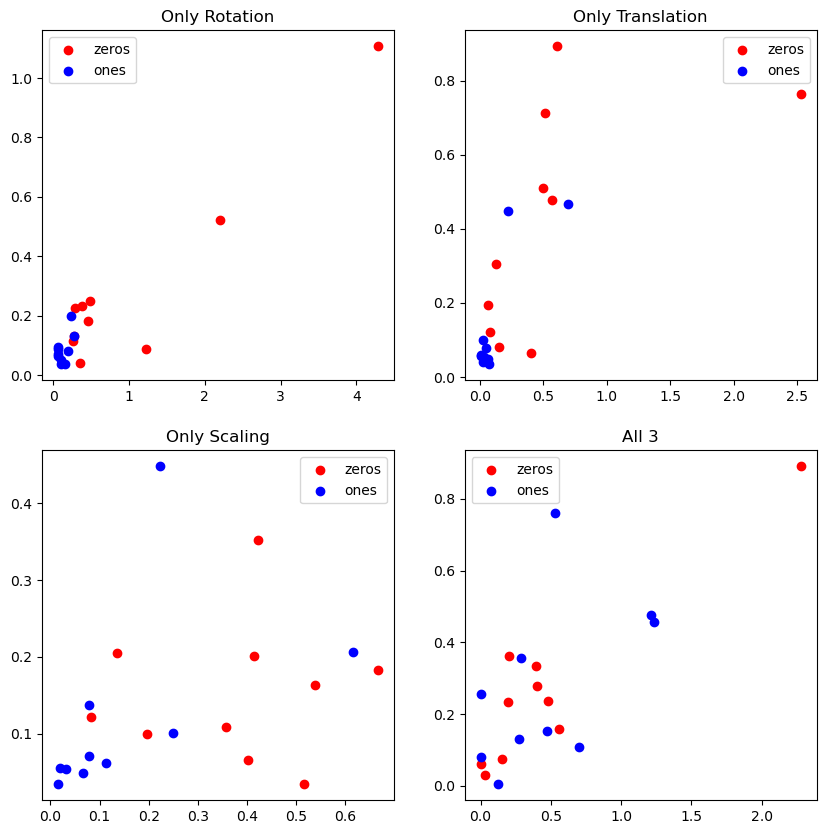

In [16]:
# Plot images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plot_descriptors(rotated_images_zeros, rotated_images_ones, 0, 0, "Only Rotation")
plot_descriptors(translated_images_zeros, translated_images_ones, 0, 1, "Only Translation")
plot_descriptors(scaled_images_zeros, scaled_images_ones, 1, 0, "Only Scaling")
plot_descriptors(transformed_images_zeros, transformed_images_ones, 1, 1, "All 3")
plt.show()

#### Discussion

In each of the 4 cases, although we still have the two 1 outliers, the ones and zeros are quite well separated.

## PART 2 - region based descriptors (10 pts)

In this part, you will use the "2"s and "3"s images.

**Objectives overview**:

**1)** *Cluster on compacity*: Based on custom definitions of perimeter and area for each image of "2" and "3" (preprocessed - by you), make a 2D plot with 2-dimensional feature vectors, similar to section 1.4. After that, define the compacity feature for each "2"s and "3"s image. Are you still able to obtain a 1D plot with values clustered in 2 well-defined regions? Discuss your findings. (**6 pts**).

**2)** *Additional method*: Choose one more region-based method (from the course or your own sources - internet allowed) and redo the 1D plot in section 2.1 (or 2D plot, depending on your choosing). Explain your method and your findings. (**4 pts**)

### 2.3. Cluster on compacity (6 pts)

In [6]:
# TODO preprocessing (simple thresholding)
threshold = 50
twos = twos_im > threshold
threes = threes_im > threshold

In [56]:
def measure_perimeter(image):
    """
    measures the perimeter og an object
    param image: image containing the object
    """
    contours = skimage.measure.find_contours(image,0.5) #finds all the contours of the object

    # Select the largest contour to discard holes inside of the object
    largest_contour = max(contours, key=len)
    return len(largest_contour)

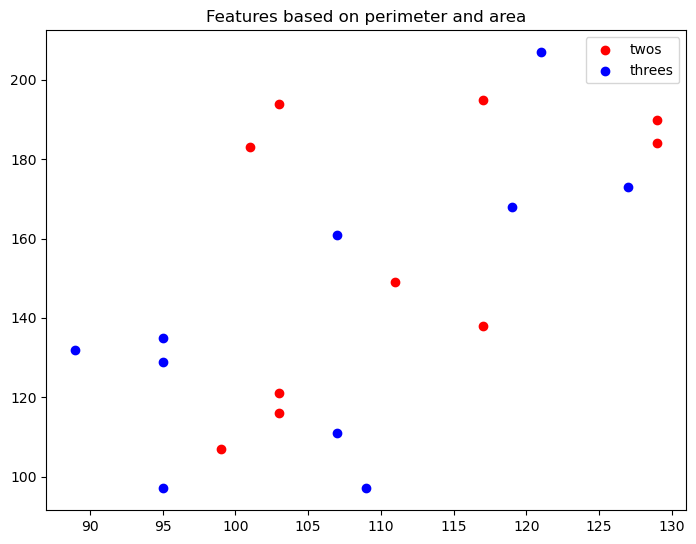

In [62]:
# TODO: Fill the arrays below with the perimeter and area as features for "2"s and "3"s images
import skimage.measure
twos_f1 = []
twos_f2 = []
threes_f1 = []
threes_f2 = []
for i in range(len(twos)):

    #twos_f1.append(skimage.measure.perimeter(twos[i,:,:], neighbourhood= 8))
    #threes_f1.append(skimage.measure.perimeter(threes[i,:,:], neighbourhood= 8))
    twos_f1.append(measure_perimeter(twos[i,:,:]))
    threes_f1.append(measure_perimeter(threes[i,:,:])) # fill in perimeter measures
    twos_f2.append(np.sum(twos[i,:,:]))
    threes_f2.append(np.sum(threes[i,:,:])) #fill in Area measures
# Plot features for all images
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.scatter(twos_f1, twos_f2, color='r', label='twos')
ax.scatter(threes_f1, threes_f2, color='b', label='threes')
ax.legend(loc='best')
plt.title("Features based on perimeter and area")
plt.show()



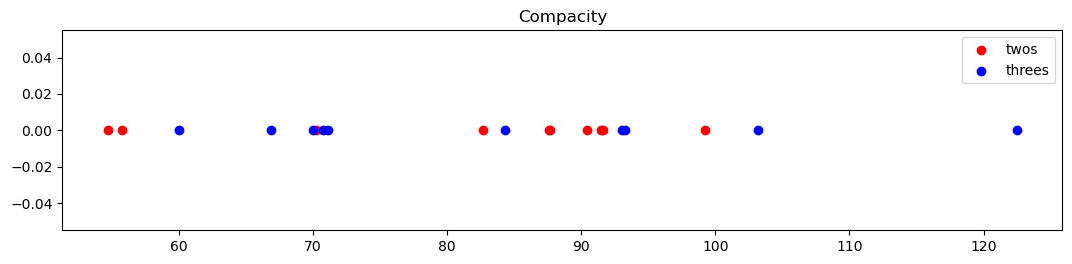

In [63]:
# TODO: Make the 1D plot of the compacity = P^2 / A
fig = plt.figure(figsize = (10,2))
ax = fig.add_axes([0,0,1,1])
ax.scatter(np.array(twos_f1)**2/np.array(twos_f2), np.zeros_like(np.array(twos_f1)), color='r', label='twos')
ax.scatter(np.array(threes_f1)**2/np.array(threes_f2),np.zeros_like(np.array(threes_f1)), color='b', label='threes')
ax.legend(loc='best')
plt.title("Compacity")
plt.show()

####  Discussion

For preprocessing we just did a simple threshoding to make the images binary. There is no further preprocessing needed since the images are not particularly noisy or low quality.<br>
to calculate the perimeter we used both the built in function of skimage and our own perimeter function. The function that we implemented does not consider small holes in the object as part of its perimeter. The results for our function as a measure of perimeter is slightly better than the built in function so we only include the better one.<br>
For area, since the images are binary we just added up all elements of each image to find its area. <br>
The perimeter, area and comacity are not good descriptors because they do not descriminate between twos and threes very well. Compacity shows how close the object is to a circle or a line. While it could be a good descriptor for 0s and 1s, 2s and 3s are both curved lines so it is reasonable to expect that they will have almost the same compacity.


TODO

### 2.2. Additional method (4 pts)

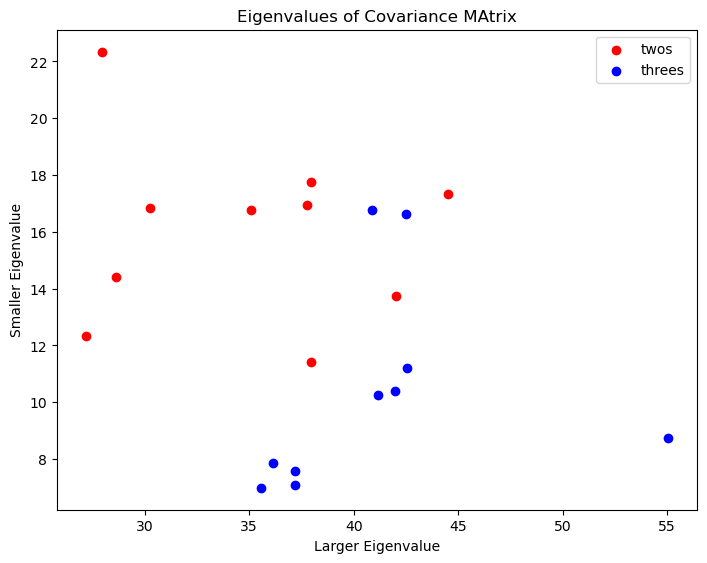

In [64]:
# TODO
twos_f3 = []
twos_f4 = []
threes_f3 = []
threes_f4 = []
for i in range(len(twos)):
    cveig2 = skimage.measure.inertia_tensor_eigvals(twos_im[i,:,:]) # find eigenvalues
    cveig3 = skimage.measure.inertia_tensor_eigvals(threes_im[i,:,:])
    twos_f3.append(cveig2[0])
    twos_f4.append(cveig2[1])
    threes_f3.append(cveig3[0])
    threes_f4.append(cveig3[1])
# plot
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.scatter(twos_f3, twos_f4, color='r', label='twos')
ax.scatter(threes_f3, threes_f4, color='b', label='threes')
ax.legend(loc='best')
plt.title("Eigenvalues of Covariance MAtrix")
plt.xlabel("Larger Eigenvalue")
plt.ylabel("Smaller Eigenvalue")
plt.show()






#### Discussion

The idea is that 3s are mostly linner than 2s. so if we project both of them on the least variance direction then the variance of 3 is less than 2. This notion is exactly the same as the notion of axes of inertia (discussed in the class). <br>
As a result, for each image we measure the covariance matrix and take its two eigenvalues(in descending order) as descriptors. the smallest eigenvalue for each image is the least possible projection variance.  <br>
As you can see in the figure above the two classes are well seperated in the feature space. The smaller eigenvalue is a good descriptor on its own and can be used alone. However, the two eigenvalues together seperate digits better. <br>


TODO

In [ ]:
# TODO

In [ ]:
# TODO: Fill the arrays below with the perimeter and area as features for "2"s and "3"s images
twos_f1 = []
twos_f2 = []
threes_f1 = []
threes_f2 = []

# Plot features for all images
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.scatter(twos_f1, twos_f2, color='r', label='twos')
ax.scatter(threes_f1, threes_f2, color='b', label='threes')
ax.legend(loc='best')
plt.title("Features based on perimeter and area")
plt.show()

In [ ]:
# TODO: Make the 1D plot of the compacity

####  Discussion

TODO

### 2.2. Additional method (4 pts)

In [ ]:
# TODO

#### Discussion

TODO